In [3]:
import numpy as np
import matplotlib.pyplot as plt

from alntk.alignment import Alignment, find_sequence

# Clustering using k-modes and k-medoids

*Written by Shoichi Yip. Last updated: 20 August 2026.*

We can cluster the sequences using two types of schemes: k-modes and k-medoids.

- k-modes. We first partition the sequences randomly into $K$ clusters. For each cluster we compute a consensus sequence: at each position we take the symbol with the highest occurrence. The representative of each cluster is this consensus sequence, which in general is not an actual sequence in the dataset. We then merge any clusters that share the same consensus sequence; we accept that this may yield fewer than $K$ clusters.
- k-medoids. We choose randomly $K$ sequences from the dataset as medoids. Each sequence is then assigned to the closest medoid. The representative of each cluster is thus an actual sequence from the dataset. We then merge any clusters that share the same medoid (or, optionally, that share the same consensus sequence as a post-processing step); we again accept that this may yield fewer than $K$ clusters.

In both cases, we then iterate as follows: assign each sequence to the cluster whose representative (consensus sequence for k-modes, medoid for k-medoids) is closest; recompute the representatives for each cluster; and repeat until convergence, defined as no change in cluster assignments between successive iterations.

In [4]:
red_sector = np.loadtxt("../data/iter_aln_v2_redsector.txt").astype(int)
red_sector_ordered = red_sector.copy()
red_sector_ordered.sort()

In [5]:
num = np.loadtxt("../data/iter_aln_v2_numbering.txt", dtype="str")

In [6]:
red_sector, num[red_sector]

(array([243, 201, 241, 228, 229, 204, 192, 189, 193, 165,   2, 242, 233,
        235, 198, 197, 177]),
 array(['228', '189', '226', '215', '216', '192', '183', '180', '184',
        '160', '18', '227', '219', '221', '188a', '188', '172'],
       dtype='<U4'))

In [7]:
aln = Alignment()
aln.import_from_fasta("../data/iter_aln_v2.faa")

In [8]:
aln_seqs = aln.get_seqs()

In [9]:
aln_seqs.shape

(89439, 265)

In [10]:
np.unique(["".join(row) for row in aln_seqs[:, red_sector]])

array(['---------GG------', '---------IG-----L', '---------IT-----Y', ...,
       'YYVYKRATSQGVPVEPI', 'YYVYKRGASQGVPVEPI', 'YYVYKYGASQGVPVNST'],
      shape=(44751,), dtype='<U17')

# Test

In [11]:
alphabet = np.array(list('ACDEFGHIKLMNPQRSTVWY-'))
aa2int = {aa: i for i, aa in enumerate(alphabet)}
int2aa = {i: aa for aa, i in aa2int.items()}

#sequences_encoded = np.vectorize(aa2int.get)(sequences).astype(np.int8)

In [12]:
#subset_size=20_000

In [13]:
#subset_indices = np.random.choice(np.arange(0, aln_seqs.shape[0]), size=subset_size, replace=False)

In [14]:
N = aln_seqs.shape[0]

In [15]:
test_aln = aln_seqs[:, red_sector_ordered].copy()
test_aln_e = np.vectorize(aa2int.get)(test_aln).astype(np.int8)

In [16]:
def get_consensus_sequence(aln):
    # aln is a 2D matrix, we take the unique counts per column
    n_rows, n_cols = aln.shape
    modes = np.zeros(n_cols, dtype=aln.dtype)
    for j in range(n_cols):
        col = aln[:, j]
        counts = np.bincount(col, minlength=21)
        modes[j] = np.argmax(counts)
    return modes

In [17]:
def get_entropy(occurrences):
    occurrences = np.array(occurrences)
    frequencies = occurrences / np.sum(occurrences)
    entropy = np.sum(- frequencies * np.log(frequencies))
    return entropy

In [18]:
k_values = [10, 100, 500, 1000, 2500, 5000, 7500, 10_000, 12_500, 15_000, 17_500, 20_000, 22_500]
num_of_cons_seq = []
entropies = []

for k in k_values:
    print(f"k is {k}")
    # random initialization
    random_integers = np.random.choice(np.arange(0, N), size=N, replace=False)
    cluster_initial_size = N // k
    clusters = {i: random_integers[i*cluster_initial_size:(i+1)*cluster_initial_size] for i in range(k)}
    
    # compute modes
    consensus_sequences = []
    for i in range(k):
        cluster_indices = clusters[i]
        consensus_sequence = get_consensus_sequence(test_aln_e[cluster_indices])
        consensus_sequences.append(consensus_sequence)
    
    unique_consensuses, consensus_counts = np.unique(consensus_sequences, axis=0, return_counts=True)
    print(f"There are {len(unique_consensuses)} unique consensus sequences.")
    
    entropies.append(get_entropy(consensus_counts))
    num_of_cons_seq.append(len(unique_consensuses))

k is 10
There are 1 unique consensus sequences.
k is 100
There are 2 unique consensus sequences.
k is 500
There are 5 unique consensus sequences.
k is 1000
There are 11 unique consensus sequences.
k is 2500
There are 34 unique consensus sequences.
k is 5000
There are 232 unique consensus sequences.
k is 7500
There are 954 unique consensus sequences.
k is 10000
There are 2472 unique consensus sequences.
k is 12500
There are 3663 unique consensus sequences.
k is 15000
There are 7211 unique consensus sequences.
k is 17500
There are 8230 unique consensus sequences.
k is 20000
There are 12056 unique consensus sequences.
k is 22500
There are 16764 unique consensus sequences.


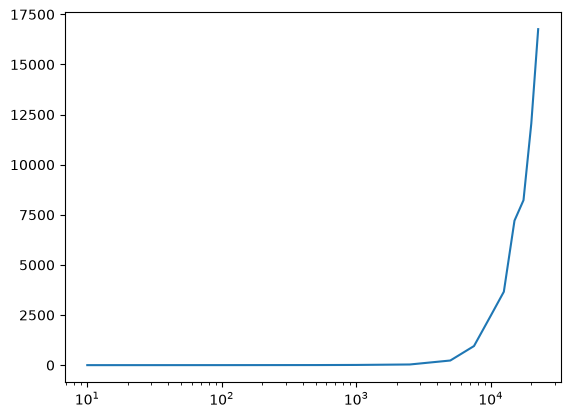

In [19]:
plt.plot(k_values, num_of_cons_seq)
plt.xscale("log")

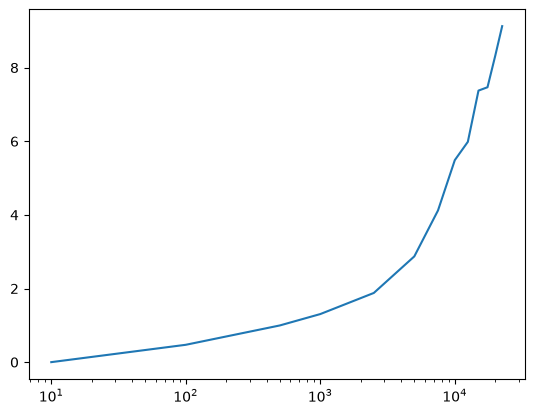

In [20]:
plt.plot(k_values, entropies)
plt.xscale("log")

In [21]:
k=5_000

print(f"k is {k}")
# random initialization
random_integers = np.random.choice(np.arange(0, N), size=N, replace=False)
cluster_initial_size = N // k
clusters = {i: random_integers[i*cluster_initial_size:(i+1)*cluster_initial_size] for i in range(k)}

# compute modes
consensus_sequences = []
for i in range(k):
    cluster_indices = clusters[i]
    consensus_sequence = get_consensus_sequence(test_aln_e[cluster_indices])
    consensus_sequences.append(consensus_sequence)

unique_consensuses, consensus_counts = np.unique(consensus_sequences, axis=0, return_counts=True)
print(f"There are {len(unique_consensuses)} unique consensus sequences.")

entropies.append(get_entropy(consensus_counts))
num_of_cons_seq.append(len(unique_consensuses))

k is 5000
There are 237 unique consensus sequences.


In [60]:
def k_modes_with_tracking(aln, k, max_iter=100):
    N, L = aln.shape
    random_integers = np.random.choice(np.arange(N), size=N, replace=False)
    cluster_initial_size = N // k
    clusters = {
        i: random_integers[i*cluster_initial_size:(i+1)*cluster_initial_size]
        for i in range(k)
    }

    consensus_sequences = []
    for i in range(k):
        idx = clusters[i]
        consensus_sequences.append(get_consensus_sequence(aln[idx]))

    unique_cons, inverse = np.unique(consensus_sequences, axis=0, return_inverse=True)
    consensus_sequences = [unique_cons[i] for i in range(len(unique_cons))]
    
    K_initial = k
    k_merged = len(consensus_sequences)
    
    new_clusters = {i: [] for i in range(len(consensus_sequences))}
    for old_i, new_i in enumerate(inverse):
        new_clusters[new_i].append(clusters[old_i])
    clusters = {i: np.concatenate(ids) if len(ids) > 0 else np.array([], dtype=int)
                for i, ids in new_clusters.items()}

    assignment_history = []
    k_active_history = []
    
    for t in range(max_iter):
        assignments = np.full(N, -1, dtype=int)
        for i, idx in clusters.items():
            assignments[idx] = i

        consensus_sequences = []
        for i in range(len(clusters)):
            idx = clusters[i]
            if len(idx) == 0:
                consensus_sequences.append(np.zeros(L, dtype=aln.dtype))
            else:
                consensus_sequences.append(get_consensus_sequence(aln[idx]))

        new_assignments = assign_clusters(aln, consensus_sequences)
        assignment_history.append(assignments.copy())
        k_active_history.append(len([i for i in clusters if len(clusters[i]) > 0]))

        if t > 0 and np.array_equal(assignment_history[-1], assignment_history[-2]):
            break

        clusters = {i: np.where(new_assignments == i)[0] for i in range(len(consensus_sequences))}

    return K_initial, k_merged, assignment_history, k_active_history

In [61]:
k = 5_000
K_initial, k_merged, assignment_history, k_active_history = k_modes_with_tracking(test_aln_e, k, max_iter=100)

In [62]:
K_initial

5000

In [63]:
k_merged

248

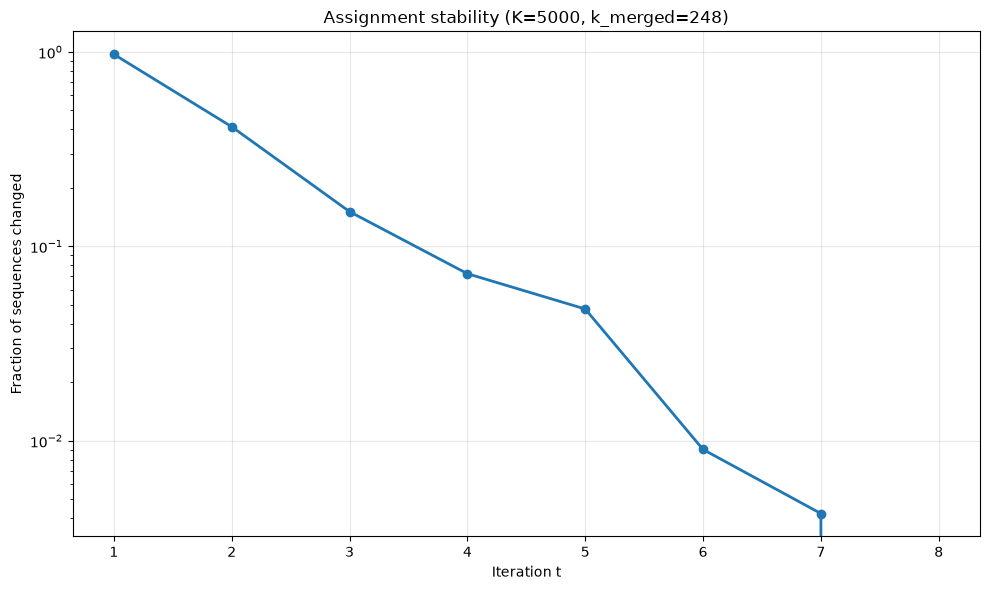

Converged at iteration: 8
Final fraction changed: 0.0


In [64]:
import matplotlib.pyplot as plt
import numpy as np

# You already have:
# k = 5_000
# K_initial, k_merged, assignment_history, k_active_history = k_modes_with_tracking(test_aln_e, k, max_iter=100)

# Compute fraction changed per iteration
changes = []
for t in range(1, len(assignment_history)):
    prev = assignment_history[t-1]
    curr = assignment_history[t]
    n_changed = np.sum(prev != curr)
    frac_changed = n_changed / len(prev)
    changes.append(frac_changed)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(changes)+1), changes, 'o-', markersize=6, linewidth=2)

plt.xlabel('Iteration t')
plt.ylabel('Fraction of sequences changed')
plt.title(f'Assignment stability (K={k}, k_merged={k_merged})')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
#plt.savefig(f'fraction_changed_K{k}.png', dpi=150)
plt.show()

print(f"Converged at iteration: {len(changes)}")
print(f"Final fraction changed: {changes[-1] if changes else 'N/A'}")

In [65]:
with open("../data/clusters_kmod_k248.txt", "w") as f:
    for cluster_label in assignment_history[-1]:
        f.write(str(cluster_label)+"\n")

In [55]:
def assign_clusters_medoids(aln, medoid_indices):
    N, L = aln.shape
    medoids = aln[medoid_indices]
    aln_exp = aln[:, None, :]
    medoids_exp = medoids[None, :, :]
    dists = np.sum(aln_exp != medoids_exp, axis=2)
    assignments = np.argmin(dists, axis=1)
    return assignments

def k_medoids_with_tracking(aln, k, max_iter=100):
    N, L = aln.shape
    
    # Random initialization: choose k sequences as medoids
    medoid_indices = np.random.choice(np.arange(N), size=k, replace=False)
    K_initial = k
    k_merged = k
    
    assignment_history = []
    medoid_history = []
    
    for t in range(max_iter):
        # Assign each sequence to nearest medoid
        assignments = assign_clusters_medoids(aln, medoid_indices)
        assignment_history.append(assignments.copy())
        medoid_history.append(medoid_indices.copy())
        
        # Recompute medoids for each cluster
        new_medoid_indices = []
        for i in range(k):
            cluster_indices = np.where(assignments == i)[0]
            if len(cluster_indices) == 0:
                new_medoid_indices.append(medoid_indices[i])
            else:
                # Find medoid: sequence with min total distance to others in cluster
                cluster_seqs = aln[cluster_indices]
                min_total_dist = np.inf
                best_idx = cluster_indices[0]
                for idx in cluster_indices:
                    dists = np.sum(aln[idx] != cluster_seqs, axis=1)
                    total_dist = np.sum(dists)
                    if total_dist < min_total_dist:
                        min_total_dist = total_dist
                        best_idx = idx
                new_medoid_indices.append(best_idx)
        
        new_medoid_indices = np.array(new_medoid_indices)
        
        # Check convergence: medoids unchanged
        if t > 0 and np.array_equal(medoid_indices, new_medoid_indices):
            break
        
        medoid_indices = new_medoid_indices
    
    return K_initial, k_merged, assignment_history, medoid_history

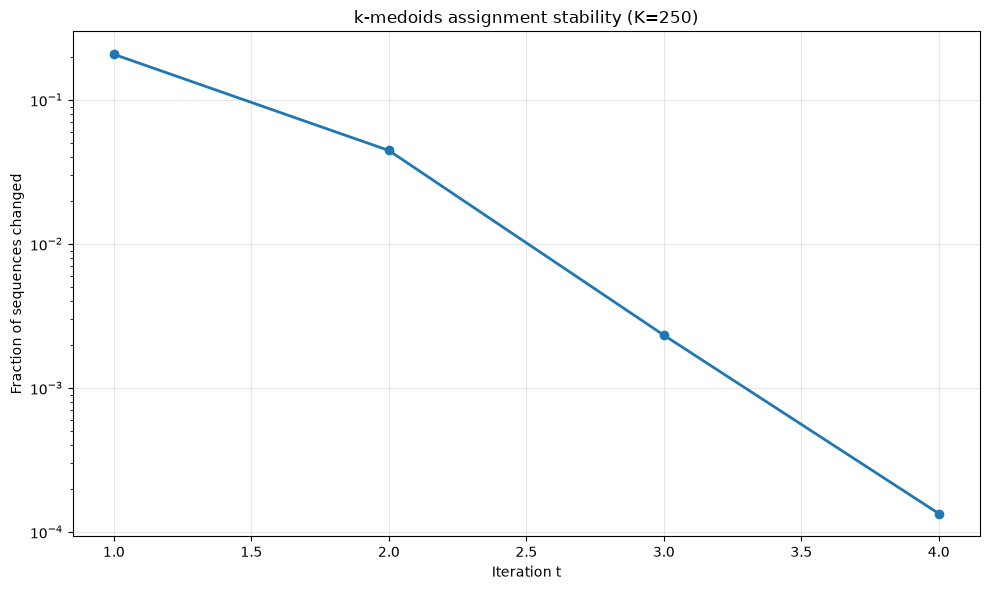

Converged at iteration: 4


In [56]:
k = 250
K_initial, k_merged, assignment_history, medoid_history = k_medoids_with_tracking(test_aln_e, k, max_iter=100)

# Compute fraction changed
changes = []
for t in range(1, len(assignment_history)):
    prev = assignment_history[t-1]
    curr = assignment_history[t]
    n_changed = np.sum(prev != curr)
    frac_changed = n_changed / len(prev)
    changes.append(frac_changed)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(changes)+1), changes, 'o-', markersize=6, linewidth=2)

plt.xlabel('Iteration t')
plt.ylabel('Fraction of sequences changed')
plt.title(f'k-medoids assignment stability (K={k})')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.savefig(f'k_medoids_fraction_changed_K{k}.png', dpi=150)
plt.show()

print(f"Converged at iteration: {len(changes)}")

In [57]:
k_merged

250

In [59]:
with open("../data/clusters_kmed_k250.txt", "w") as f:
    for cluster_label in assignment_history[-1]:
        f.write(str(cluster_label)+"\n")